# SNR-sweep scatterplot review

This notebook reuses the review layout of `D_S1_gate1_snr_preview.ipynb`, but every scatterplot comes directly from `D_S3_snr_sweep_generation.ipynb` and every displayed metric comes from `D_S4_snr_sweep_metrics.ipynb`.

The default grid keeps a high-SNR anchor at 100 and adds denser transition coverage at 20, 15, 10, and 7 before the earlier practical levels. It is label-neutral: borders do not encode a pre-assigned human label.

In [1]:
from __future__ import annotations

import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)

def locate_repo_root() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in candidates:
        if (root / 'D' / 'Global' / 'D_S3_snr_sweep_generation.ipynb').exists():
            return root
    raise FileNotFoundError('Could not locate D/Global/D_S3_snr_sweep_generation.ipynb')

REPO_ROOT = locate_repo_root()
GLOBAL_DIR = REPO_ROOT / 'D' / 'Global'
S3_OUTPUT_DIR = GLOBAL_DIR / 'output' / 'S3_snr_mic_sweep'
OUTPUT_DIR = GLOBAL_DIR / 'output' / 'S6_snr_sweep_manual_review'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CASES_PATH = S3_OUTPUT_DIR / 'cases.csv'
POINTS_PATH = S3_OUTPUT_DIR / 'scatter_points.npz'
METRICS_PATH = S3_OUTPUT_DIR / 'metrics_full.parquet'
for required_path in [CASES_PATH, POINTS_PATH, METRICS_PATH]:
    if not required_path.exists():
        raise FileNotFoundError(f'Missing {required_path}. Run D_S3 and D_S4 first.')

print(f'Cases:   {CASES_PATH}')
print(f'Points:  {POINTS_PATH}')
print(f'Metrics: {METRICS_PATH}')
print(f'Output:  {OUTPUT_DIR}')

Cases:   /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S3_snr_mic_sweep/cases.csv
Points:  /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S3_snr_mic_sweep/scatter_points.npz
Metrics: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S3_snr_mic_sweep/metrics_full.parquet
Output:  /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S6_snr_sweep_manual_review


## Review controls

The three variant switches and the requested SNR list are the main controls. `SNR_REVIEW_MODE=smoke` uses a small subset for a quick execution check; normal notebook execution uses the full review design.

In [2]:
REVIEW_MODE = os.environ.get('SNR_REVIEW_MODE', 'full').strip().lower()
if REVIEW_MODE not in {'full', 'smoke'}:
    raise ValueError("SNR_REVIEW_MODE must be 'full' or 'smoke'")

FAMILY_SPECS = [
    ('F01', 'Linear'),
    ('F03', 'Power convex'),
    ('F05', 'Power concave'),
    ('F07', 'Saturation'),
    ('F13', 'S-curve'),
    ('F15', 'Threshold'),
    ('F18', 'U-shape'),
    ('F21', 'Cubic'),
    ('F19', 'Spike'),
    ('F23', 'Two Lines'),
    ('F24', 'Line + Parabola'),
    ('F25', 'Multi-regime'),
    ('F26', 'Windowed J'),
    ('F22', 'Oscillation'),
]

# Three independent switches. Strong is the default review set.
include_mild = False
include_standard = False
include_strong = True

variant_switches = {
    'mild': include_mild,
    'standard': include_standard,
    'strong': include_strong,
}
SELECTED_VARIANTS = [name for name, enabled in variant_switches.items() if enabled]
if not SELECTED_VARIANTS:
    raise ValueError('Enable at least one of include_mild/include_standard/include_strong.')

# Smaller noise means higher SNR. Extra coverage is concentrated around 20-5.
REQUESTED_SNR = [100.0, 20.0, 15.0, 10.0, 7.0, 5.0, 4.0, 3.0,
                 2.0, 1.5, 1.0, 0.8, 0.5, 0.4, 0.3, 0.1]
SELECTED_REPEATS = [1, 2]

# Metrics are loaded from D_S4. Keep only MIC for a cleaner plot, or add MEV/dCor.
METRIC_ANNOTATIONS = ['MIC']  # options: 'MIC', 'MEV', 'dCor'
INCLUDE_NULL = True
N_NULL = 32
NULL_SELECTION_SEED = 2026072001
NULLS_PER_PAGE = 25

if REVIEW_MODE == 'smoke':
    FAMILY_SPECS = [spec for spec in FAMILY_SPECS if spec[0] in {'F23', 'F24'}]
    SELECTED_VARIANTS = ['strong']
    REQUESTED_SNR = [20.0, 10.0, 5.0, 3.0]
    SELECTED_REPEATS = [1]
    INCLUDE_NULL = False

print(f'Review mode: {REVIEW_MODE}')
print(f'Families: {len(FAMILY_SPECS)}; variants: {SELECTED_VARIANTS}')
print(f'Requested SNR levels: {REQUESTED_SNR}')
print(f'Repeats: {SELECTED_REPEATS}; metric annotations: {METRIC_ANNOTATIONS}')

Review mode: full
Families: 14; variants: ['strong']
Requested SNR levels: [100.0, 20.0, 15.0, 10.0, 7.0, 5.0, 4.0, 3.0, 2.0, 1.5, 1.0, 0.8, 0.5, 0.4, 0.3, 0.1]
Repeats: [1, 2]; metric annotations: ['MIC']


## Match S3 cases to the requested SNR levels and join S4 metrics

The S3 grid is dense but does not contain every round number exactly. Each requested value is therefore mapped once to its nearest S3 nominal SNR. The original `case_id` and `candidate_index` are preserved.

In [3]:
cases = pd.read_csv(CASES_PATH, low_memory=False)
metrics = pd.read_parquet(
    METRICS_PATH,
    columns=['case_id', 'MIC', 'MEV', 'distance_correlation'],
).rename(columns={'distance_correlation': 'dCor'})

if not cases['case_id'].is_unique or not metrics['case_id'].is_unique:
    raise ValueError('case_id must be unique in both S3 cases and S4 metrics.')

signal_cases = cases.loc[~cases['is_null'].astype(bool)].copy()
available_snr = np.sort(signal_cases['nominal_snr'].dropna().unique())

def nearest_s3_snr(requested: float) -> float:
    return float(available_snr[np.argmin(np.abs(available_snr - float(requested)))])

snr_map = pd.DataFrame({'requested_snr': REQUESTED_SNR})
snr_map['matched_nominal_snr'] = snr_map['requested_snr'].map(nearest_s3_snr)
snr_map['relative_error_percent'] = 100.0 * (
    snr_map['matched_nominal_snr'] - snr_map['requested_snr']
) / snr_map['requested_snr']
if not snr_map['matched_nominal_snr'].is_unique:
    raise ValueError('Two requested SNR values map to the same S3 level; revise REQUESTED_SNR.')
display(snr_map.round({'matched_nominal_snr': 6, 'relative_error_percent': 2}))

family_ids = [family_id for family_id, _ in FAMILY_SPECS]
matched_levels = snr_map['matched_nominal_snr'].to_numpy(dtype=float)
selection = signal_cases[
    signal_cases['family_id'].isin(family_ids)
    & signal_cases['variant_level'].isin(SELECTED_VARIANTS)
    & signal_cases['repeat'].isin(SELECTED_REPEATS)
    & signal_cases['nominal_snr'].isin(matched_levels)
].copy()

selection = selection.merge(metrics, on='case_id', how='left', validate='one_to_one')
requested_by_matched = dict(zip(snr_map['matched_nominal_snr'], snr_map['requested_snr']))
selection['requested_snr'] = selection['nominal_snr'].map(requested_by_matched)
selection['human_label'] = np.nan
selection['review_status'] = 'pending_manual_review'

expected = (
    len(FAMILY_SPECS) * len(SELECTED_VARIANTS)
    * len(SELECTED_REPEATS) * len(REQUESTED_SNR)
)
if len(selection) != expected:
    raise ValueError(f'Expected {expected} selected signal cases; found {len(selection)}.')
if selection[['MIC', 'MEV', 'dCor']].isna().any().any():
    raise ValueError('At least one selected S3 case is missing an S4 metric.')

selection = selection.sort_values(
    ['variant_level', 'repeat', 'family_id', 'requested_snr'],
    ascending=[True, True, True, False],
).reset_index(drop=True)
selection['loaded_position'] = np.arange(len(selection), dtype=int)

array_indices = selection['candidate_index'].to_numpy(dtype=int)
with np.load(POINTS_PATH) as point_store:
    x_selected = point_store['x'][array_indices].copy()
    y_selected = point_store['y'][array_indices].copy()

print(f'Selected {len(selection):,} signal cases from S3 and joined S4 metrics.')
display(selection[[
    'case_id', 'candidate_index', 'family_id', 'variant_level', 'repeat',
    'requested_snr', 'nominal_snr', 'actual_snr', 'MIC', 'MEV', 'dCor',
]].head(12))

,requested_snr,matched_nominal_snr,relative_error_percent
0,100.0,100.000000,0.00
1,20.0,19.756319,-1.22
2,15.0,15.175880,1.17
3,10.0,10.217053,2.17
4,7.0,6.878558,-1.73
5,5.0,4.946605,-1.07
6,4.0,4.058757,1.47
7,3.0,2.918790,-2.71
8,2.0,1.965055,-1.75
9,1.5,1.509463,0.63


Selected 448 signal cases from S3 and joined S4 metrics.


,case_id,candidate_index,family_id,variant_level,repeat,requested_snr,nominal_snr,actual_snr,MIC,MEV,dCor
0,S004716,4715,F01,strong,1,100.0,100.000000,110.547679,1.000000,1.000000,0.995032
1,S004691,4690,F01,strong,1,20.0,19.756319,21.840152,0.941900,0.941900,0.976700
2,S004687,4686,F01,strong,1,15.0,15.175880,16.776583,0.939544,0.939544,0.970219
3,S004681,4680,F01,strong,1,10.0,10.217053,11.294715,0.894174,0.894174,0.957184
4,S004675,4674,F01,strong,1,7.0,6.878558,7.604086,0.859815,0.859815,0.938949
5,S004670,4669,F01,strong,1,5.0,4.946605,5.468356,0.835789,0.835789,0.918638
6,S004667,4666,F01,strong,1,4.0,4.058757,4.486862,0.811768,0.811768,0.903707
7,S004662,4661,F01,strong,1,3.0,2.918790,3.226655,0.779908,0.779908,0.873609
8,S004656,4655,F01,strong,1,2.0,1.965055,2.172322,0.687236,0.687236,0.827910
9,S004652,4651,F01,strong,1,1.5,1.509463,1.668676,0.628592,0.628592,0.791343


## Signal review grids

One figure is produced per variant and repeat. Rows are families and columns are requested SNR levels. No fitted curve is added.

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S6_snr_sweep_manual_review/snr_sweep_review_strong_repeat_01.png


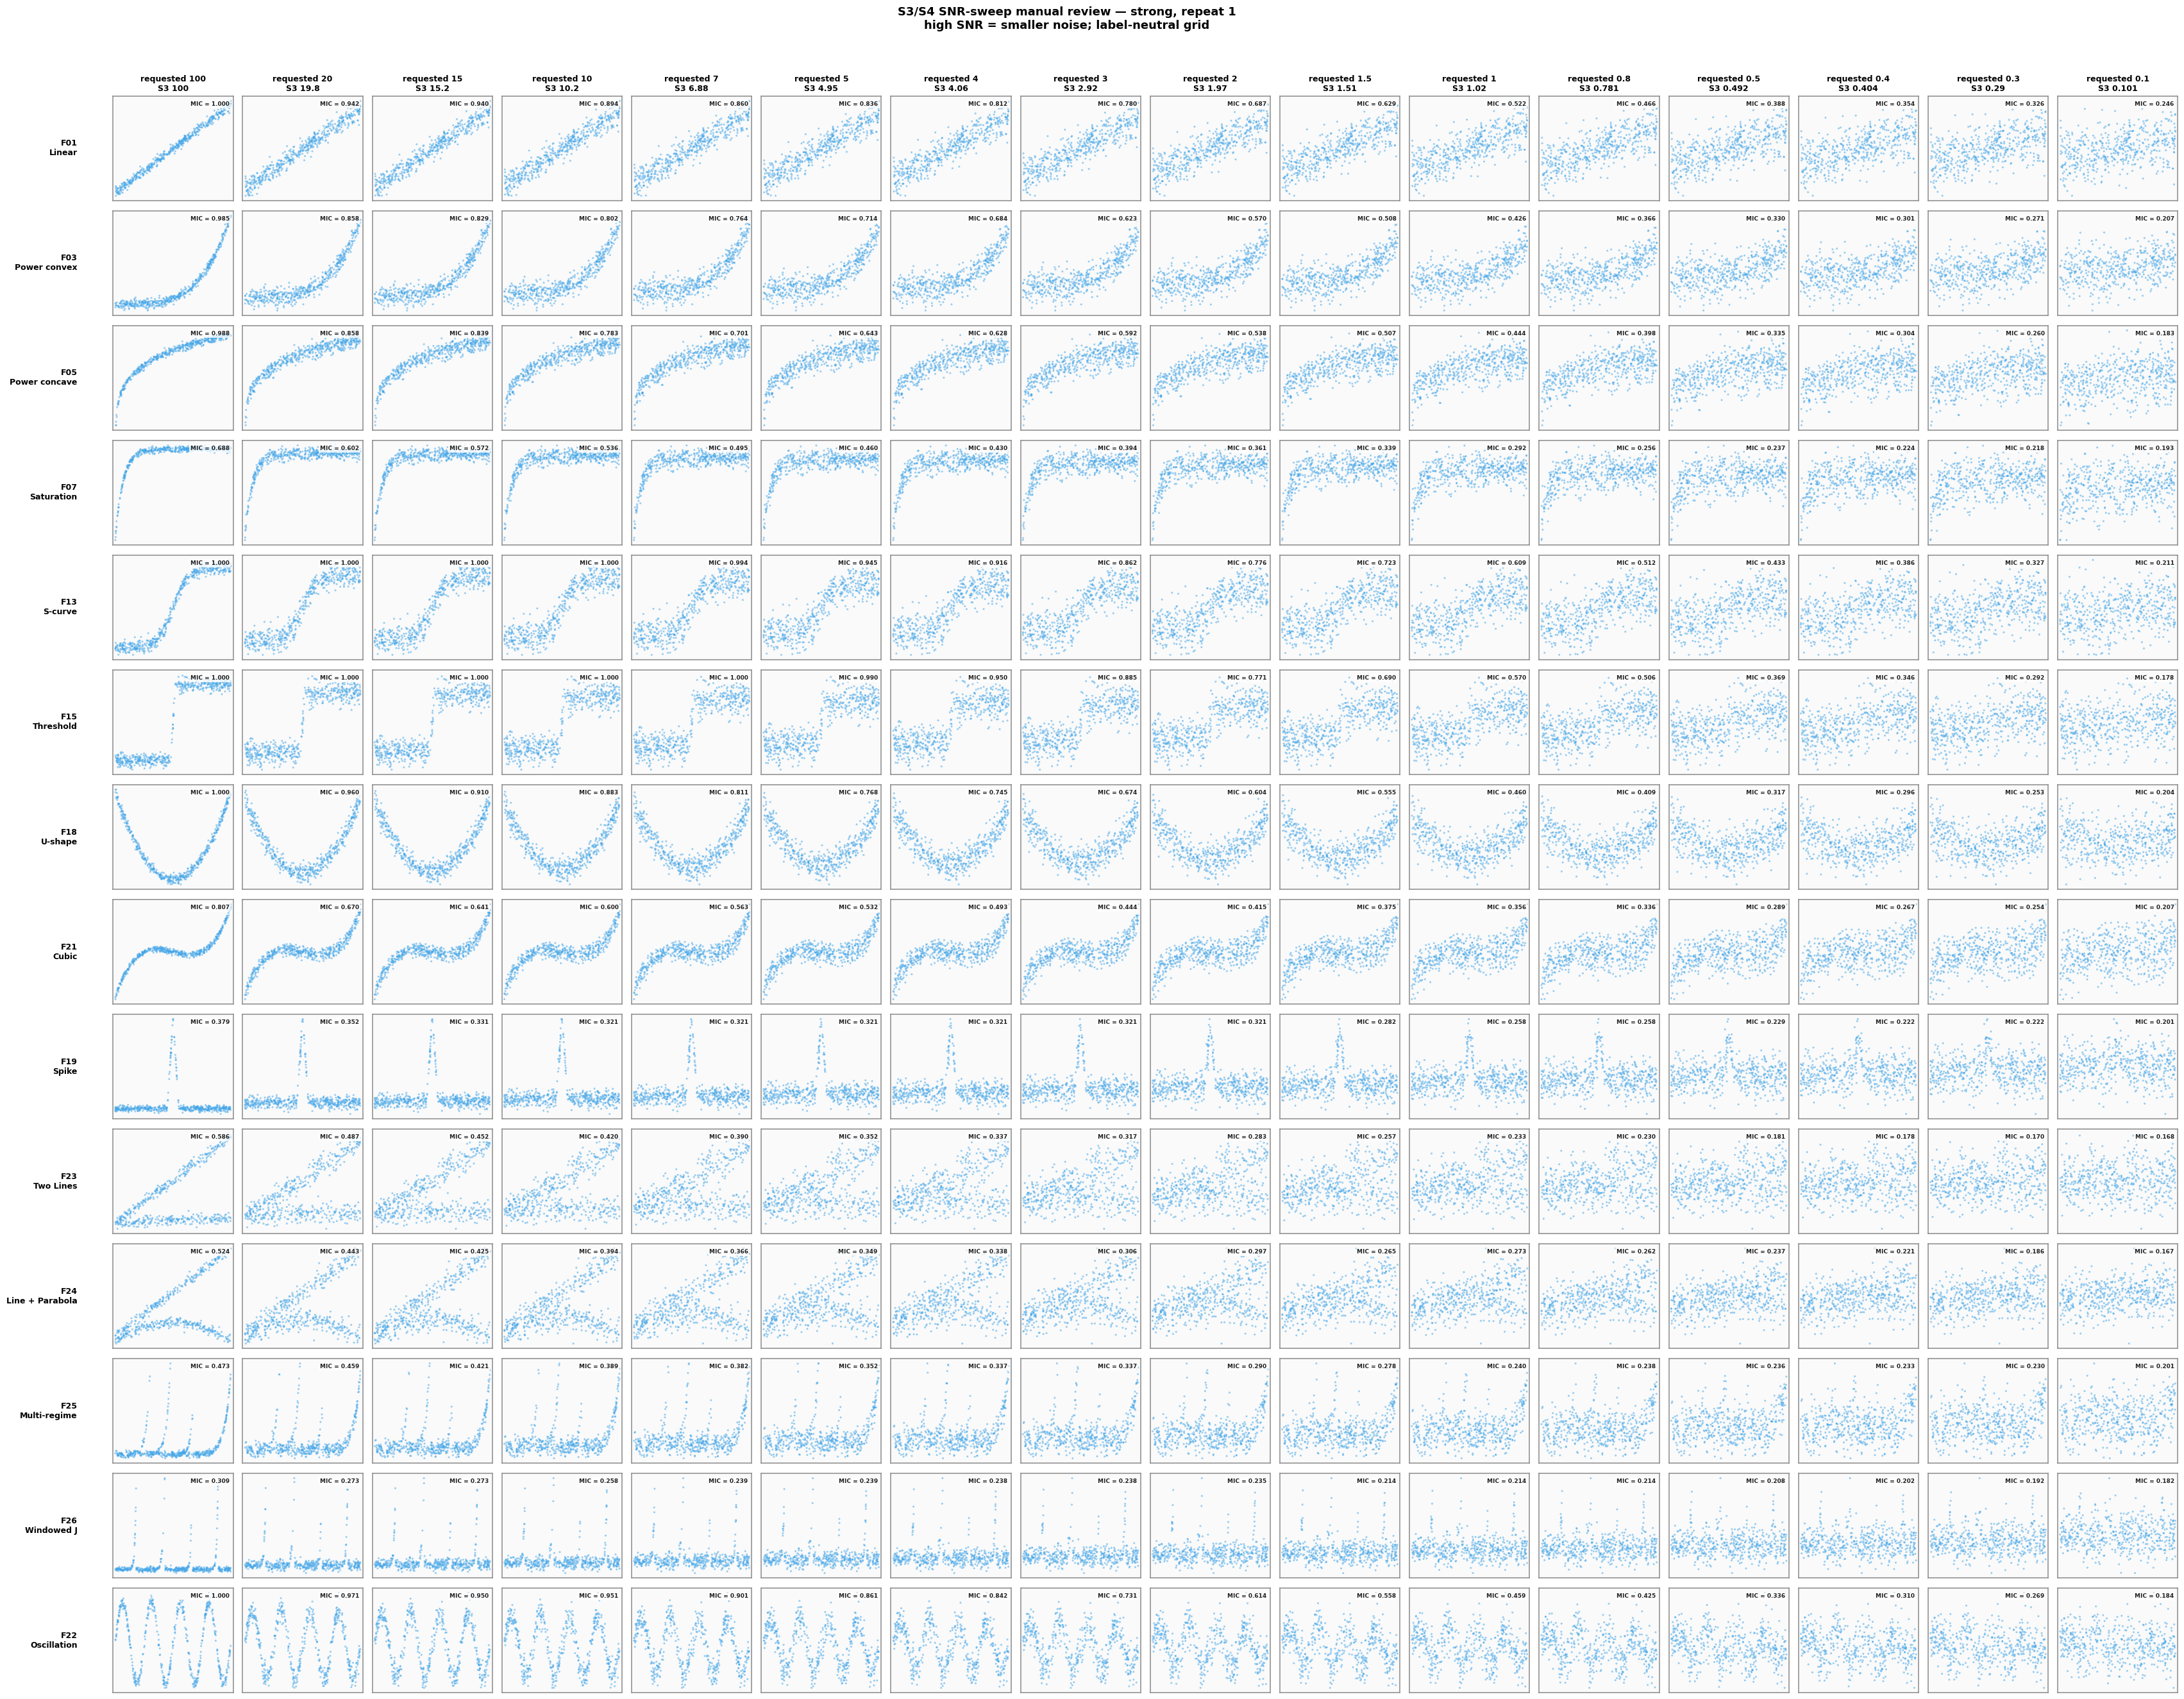

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S6_snr_sweep_manual_review/snr_sweep_review_strong_repeat_02.png


In [4]:
def metric_text(record: pd.Series) -> str:
    labels = {'MIC': 'MIC', 'MEV': 'MEV', 'dCor': 'dCor'}
    return '\n'.join(f"{labels[name]} = {float(record[name]):.3f}" for name in METRIC_ANNOTATIONS)

def annotate_metrics(ax, record: pd.Series) -> None:
    if not METRIC_ANNOTATIONS:
        return
    ax.text(
        0.97, 0.95, metric_text(record),
        transform=ax.transAxes, ha='right', va='top',
        fontsize=6.5, fontweight='bold', color='#222222',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.78, pad=1.3),
        zorder=10,
    )

for stale_path in OUTPUT_DIR.glob('snr_sweep_review_*.png'):
    stale_path.unlink()

signal_figure_paths = []
nrows, ncols = len(FAMILY_SPECS), len(REQUESTED_SNR)

for variant_level in SELECTED_VARIANTS:
    for repeat in SELECTED_REPEATS:
        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(2.05 * ncols + 2.2, 1.78 * nrows + 2.0),
            squeeze=False,
        )

        for row_idx, (family_id, short_name) in enumerate(FAMILY_SPECS):
            for col_idx, requested_snr in enumerate(REQUESTED_SNR):
                record = selection[
                    selection['family_id'].eq(family_id)
                    & selection['variant_level'].eq(variant_level)
                    & selection['repeat'].eq(repeat)
                    & selection['requested_snr'].eq(float(requested_snr))
                ]
                if len(record) != 1:
                    raise ValueError(
                        f'Expected one case for {family_id}, {variant_level}, '
                        f'repeat {repeat}, requested SNR {requested_snr}; found {len(record)}.'
                    )
                record = record.iloc[0]
                pos = int(record['loaded_position'])
                ax = axes[row_idx, col_idx]
                ax.scatter(
                    x_selected[pos], y_selected[pos],
                    s=5, alpha=0.52, color='#42A5E8',
                    edgecolors='none', rasterized=True,
                )
                annotate_metrics(ax, record)
                ax.set_xlim(-0.02, 1.02)
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_facecolor('#FAFAFA')
                for spine in ax.spines.values():
                    spine.set_color('#8A8A8A')
                    spine.set_linewidth(1.1)

                if row_idx == 0:
                    ax.set_title(
                        f"requested {requested_snr:g}\nS3 {float(record['nominal_snr']):.3g}",
                        fontsize=9, fontweight='bold', pad=6,
                    )
                if col_idx == 0:
                    ax.set_ylabel(
                        f'{family_id}\n{short_name}',
                        fontsize=9, fontweight='bold', rotation=0,
                        ha='right', va='center', labelpad=40,
                    )

        fig.suptitle(
            f'S3/S4 SNR-sweep manual review — {variant_level}, repeat {repeat}\n'
            'high SNR = smaller noise; label-neutral grid',
            fontsize=13, fontweight='bold', y=0.997,
        )
        # Reserve a fixed physical header band; this also prevents overlap in smoke mode.
        axes_top = min(0.945, 1.0 - 0.90 / fig.get_figheight())
        fig.subplots_adjust(
            left=0.075, right=0.995, bottom=0.02, top=axes_top,
            wspace=0.08, hspace=0.10,
        )
        figure_path = OUTPUT_DIR / f'snr_sweep_review_{variant_level}_repeat_{repeat:02d}.png'
        fig.savefig(figure_path, dpi=180, bbox_inches='tight', facecolor='white')
        signal_figure_paths.append(figure_path)
        print(f'Saved: {figure_path}')
        if repeat == SELECTED_REPEATS[0]:
            plt.show()
        else:
            plt.close(fig)

## Null controls from S3/S4

Null has no SNR. These panels use the 100 independent Null cases already generated by S3 and the metrics already computed by S4.

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S6_snr_sweep_manual_review/snr_sweep_null_001_025.png


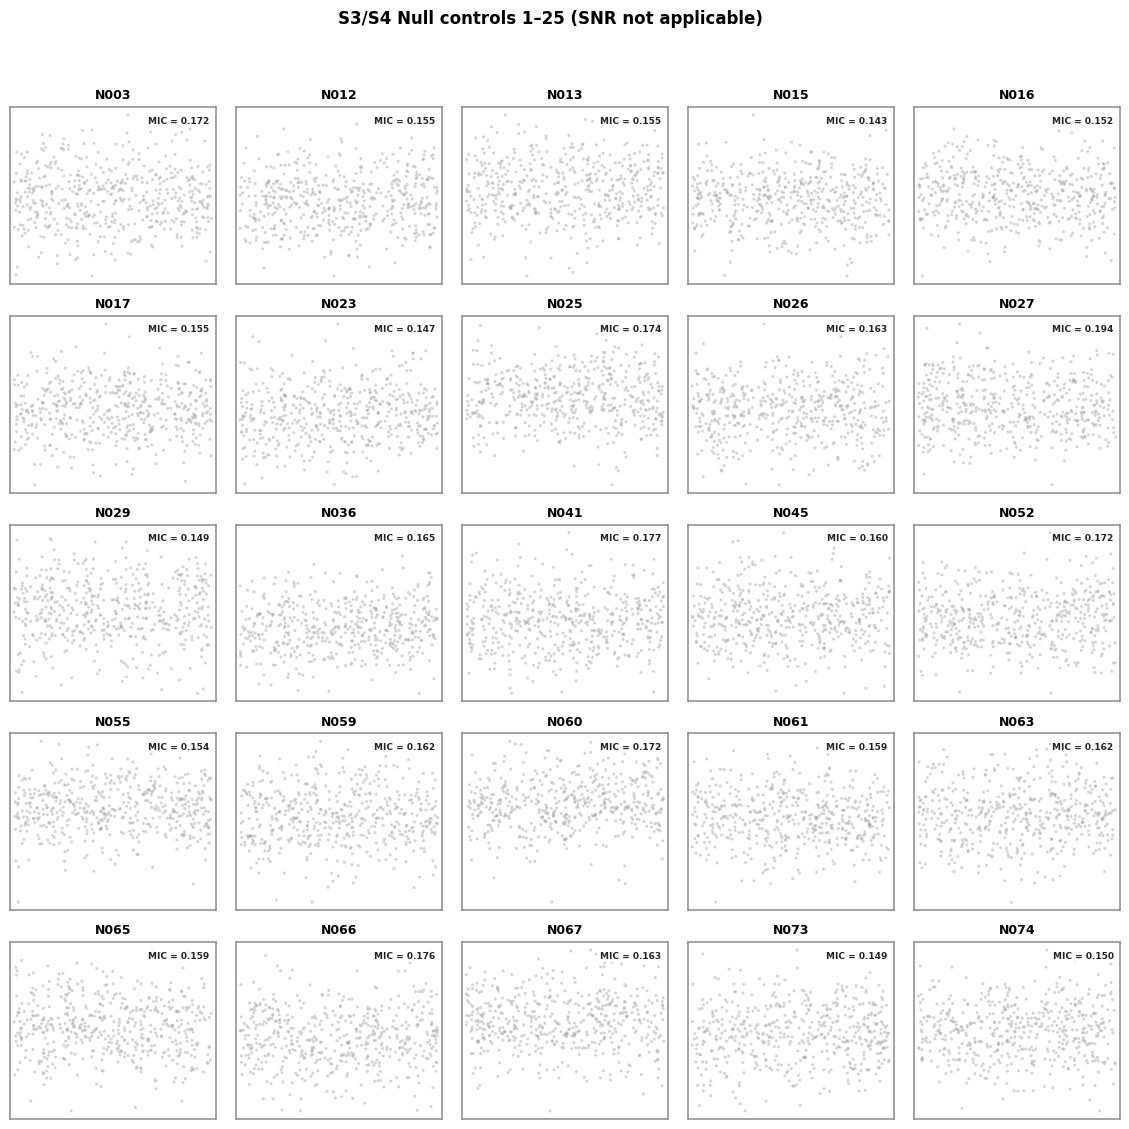

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S6_snr_sweep_manual_review/snr_sweep_null_026_032.png
Loaded 32 independent Null controls from S3/S4.


In [5]:
null_selection = pd.DataFrame()
null_figure_paths = []

if INCLUDE_NULL:
    for stale_path in OUTPUT_DIR.glob('snr_sweep_null_*.png'):
        stale_path.unlink()

    null_pool = cases.loc[cases['is_null'].astype(bool)].copy()
    if len(null_pool) < N_NULL:
        raise ValueError(f'Requested {N_NULL} Null cases, but S3 contains only {len(null_pool)}.')
    null_selection = null_pool.sample(n=N_NULL, replace=False, random_state=NULL_SELECTION_SEED)
    null_selection = null_selection.merge(metrics, on='case_id', how='left', validate='one_to_one')
    null_selection['requested_snr'] = np.nan
    null_selection['human_label'] = np.nan
    null_selection['reference_label'] = 0.0
    null_selection['review_status'] = 'pending_manual_review'
    null_selection = null_selection.sort_values('repeat').reset_index(drop=True)
    if null_selection[['MIC', 'MEV', 'dCor']].isna().any().any():
        raise ValueError('At least one S3 Null case is missing an S4 metric.')

    null_indices = null_selection['candidate_index'].to_numpy(dtype=int)
    with np.load(POINTS_PATH) as point_store:
        x_null = point_store['x'][null_indices].copy()
        y_null = point_store['y'][null_indices].copy()

    for page_start in range(0, len(null_selection), NULLS_PER_PAGE):
        page_stop = min(page_start + NULLS_PER_PAGE, len(null_selection))
        page = null_selection.iloc[page_start:page_stop]
        n_page = len(page)
        ncols_null = 5
        nrows_null = math.ceil(n_page / ncols_null)
        fig, axes = plt.subplots(
            nrows_null, ncols_null,
            figsize=(11.5, 2.1 * nrows_null + 1.0), squeeze=False,
        )
        for local_idx, (_, record) in enumerate(page.iterrows()):
            ax = axes.flat[local_idx]
            source_idx = page_start + local_idx
            ax.scatter(
                x_null[source_idx], y_null[source_idx],
                s=5, alpha=0.48, color='#A9A9A9',
                edgecolors='none', rasterized=True,
            )
            annotate_metrics(ax, record)
            ax.set_xlim(-0.02, 1.02)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(str(record['case_id']), fontsize=9, fontweight='bold')
            for spine in ax.spines.values():
                spine.set_color('#8A8A8A')
                spine.set_linewidth(1.1)
        for empty_idx in range(n_page, nrows_null * ncols_null):
            axes.flat[empty_idx].axis('off')

        fig.suptitle(
            f'S3/S4 Null controls {page_start + 1}–{page_stop} (SNR not applicable)',
            fontsize=12, fontweight='bold', y=0.995,
        )
        fig.subplots_adjust(left=0.03, right=0.995, bottom=0.03, top=0.91, wspace=0.10, hspace=0.18)
        figure_path = OUTPUT_DIR / f'snr_sweep_null_{page_start + 1:03d}_{page_stop:03d}.png'
        fig.savefig(figure_path, dpi=180, bbox_inches='tight', facecolor='white')
        null_figure_paths.append(figure_path)
        print(f'Saved: {figure_path}')
        if page_start == 0:
            plt.show()
        else:
            plt.close(fig)

    print(f'Loaded {len(null_selection)} independent Null controls from S3/S4.')

## Export the selected-case manifest

The manifest records family, variant, repeat, requested/matched/actual SNR, S3 identifiers, and the three S4 metrics. `human_label` is deliberately left empty.

In [6]:
signal_manifest = selection.drop(columns=['loaded_position']).copy()
signal_manifest['reference_label'] = np.nan
signal_manifest['source_dataset'] = 'D_S3_snr_sweep_generation (full)'
signal_manifest['metrics_source'] = 'D_S4_snr_sweep_metrics (full)'

manifest_parts = [signal_manifest]
if INCLUDE_NULL:
    null_manifest = null_selection.copy()
    null_manifest['source_dataset'] = 'D_S3_snr_sweep_generation (full)'
    null_manifest['metrics_source'] = 'D_S4_snr_sweep_metrics (full)'
    manifest_parts.append(null_manifest)

review_manifest = pd.concat(manifest_parts, ignore_index=True, sort=False)
review_manifest.insert(0, 'review_index', np.arange(1, len(review_manifest) + 1, dtype=int))

manifest_path = OUTPUT_DIR / 'snr_sweep_manual_review_manifest.csv'
review_manifest.to_csv(manifest_path, index=False)

print(f'Manifest: {manifest_path}')
print(f'Signal cases: {len(signal_manifest):,}')
print(f'Null cases: {len(null_selection):,}' if INCLUDE_NULL else 'Null cases: not included')
print(f'Total cases: {len(review_manifest):,}')
display(
    review_manifest.groupby(['family_id', 'variant_level'], dropna=False)
    .size().rename('selected_cases').reset_index()
)

Manifest: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S6_snr_sweep_manual_review/snr_sweep_manual_review_manifest.csv
Signal cases: 448
Null cases: 32
Total cases: 480


,family_id,variant_level,selected_cases
0,F01,strong,32
1,F03,strong,32
2,F05,strong,32
3,F07,strong,32
4,F13,strong,32
5,F15,strong,32
6,F18,strong,32
7,F19,strong,32
8,F21,strong,32
9,F22,strong,32
